# PCA and Kernel PCA Analysis



This notebook analyzes PCA on the Iris dataset and investigates the limitations of linear methods on nonlinear data using Kernel PCA.


## Part (a): PCA on Iris Dataset
In this section, we will:
1.  Load and standardize the Iris dataset.
2.  Apply PCA to reduce dimensions from 4 to 2.
3.  Visualize the results.
4.  Analyze the variance and separability.
5.  Discuss these results in the context of classification and compare with LDA.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

np.random.seed(42)

Eigenvalues: [2.93808505 0.9201649 ]
Explained Variance Ratio: [0.72962445 0.22850762]
Total Explained Variance: 0.9581


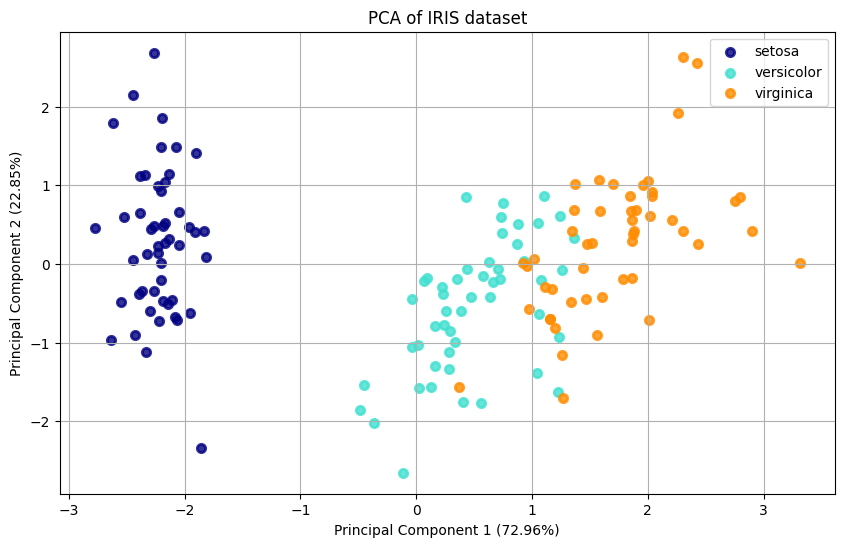

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_

print(f"Eigenvalues: {eigenvalues}")
print(f"Explained Variance Ratio: {explained_variance_ratio}")
print(f"Total Explained Variance: {np.sum(explained_variance_ratio):.4f}")

plt.figure(figsize=(10, 6))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=.8, lw=lw,
                label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of IRIS dataset')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.grid(True)
plt.show()

### Analysis of PCA Results

**1. Explained Variance:**
The first principal component (PC1) captures the largest amount of variance. This is inherent to the definition of PCA: it iteratively finds the orthogonal direction with the maximum variance in the data.

**2. Class Separability:**
The classes appear to be reasonably well separated, especially the Setosa class (Cluster 1). However, there is some overlap between Versicolor and Virginica in the 2D plane. 
*   **Reasoning:** PCA is an **unsupervised** method. Its objective is to maximize *total variance*, $ \text{Var}(X_{projected}) $, regardless of class labels. It does not try to maximize the separation between class means. The fact that they separate well indicates that the directions of maximum variance in the data also happen to be directions that differentiate the species (biologically, size variations correlate with species).

**3. Appropriateness for Classification:**
Is PCA appropriate for classification?
*   **Yes, but with caveats.** It is often used as a preprocessing step to reduce dimensionality and noise, which can improve classifier performance (avoiding the curse of dimensionality).
*   **No, strictly speaking.** Since it ignores labels, it might discard low-variance features that are actually highly discriminative for specific classes. For purely maximizing class separation, discriminant analysis is theoretically superior.

---

### Comparison with Linear Discriminant Analysis (LDA)

If we used **LDA** instead of PCA, the projection would differ fundamentally:

1.  **Objective Function:**
    *   **PCA:** Maximizes variation ($ \mathbf{w}^T \Sigma \mathbf{w} $).
    *   **LDA:** Maximizes the ratio of **between-class variance** to **within-class variance** ($ \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}} $).

2.  **Conceptual Result:**
    *   LDA computes directions (linear discriminants) that push the means of the classes as far apart as possible while making the spread of each class as tight as possible.
    *   The resulting plot would likely show the three classes much more tightly clustered and clearly separated, as the projection is explicitly optimized for this separability using the class labels $y$, which PCA ignored.

## Part (b): Nonlinear Data and Kernel PCA

In this section, we will:
1.  Generate a non-linearly separable dataset (nested circles).
2.  Apply Standard PCA and visualize why it fails.
3.  Apply Kernel PCA with an RBF kernel and visualize how it succeeds.
4.  Discuss the role of the kernel trick.

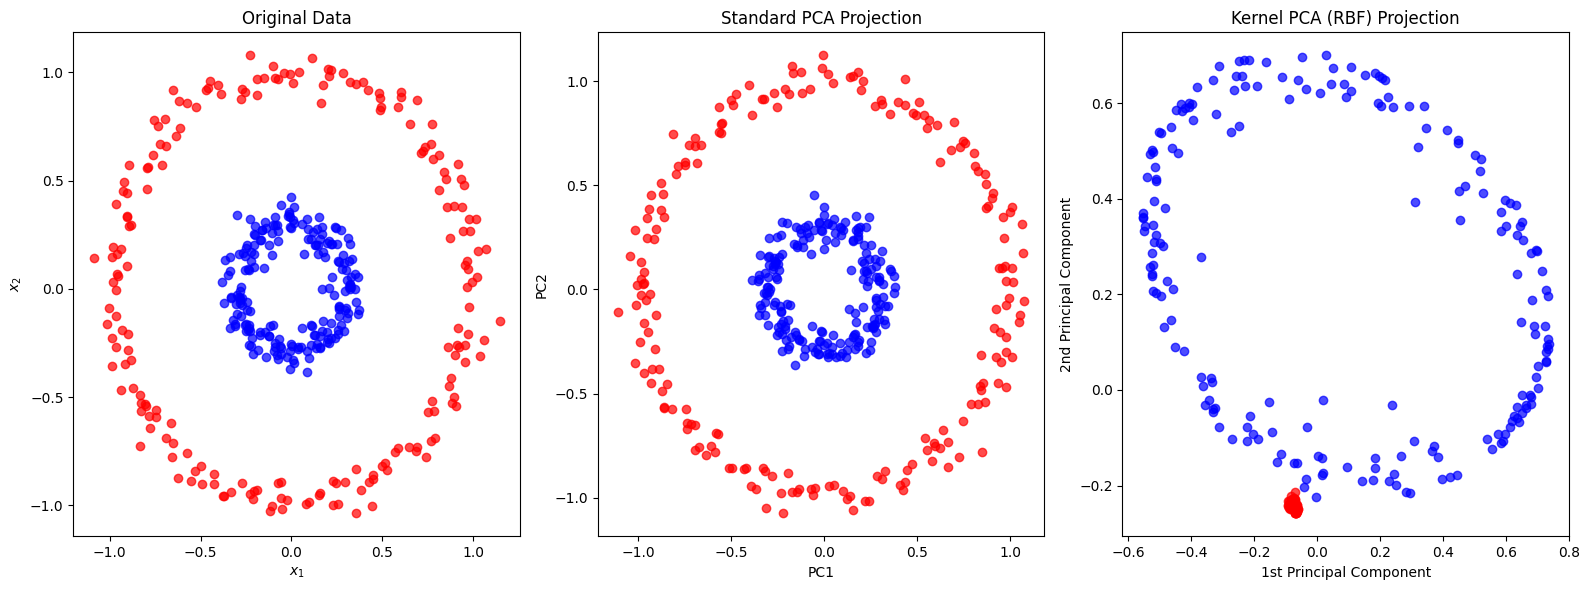

In [ ]:
X_circles, y_circles = make_circles(n_samples=400, factor=.3, noise=.05, random_state=42)

pca_circles = PCA(n_components=2)
X_pca_circles = pca_circles.fit_transform(X_circles)

kpca = KernelPCA(n_components=2, kernel="rbf", gamma=10, fit_inverse_transform=True)
X_kpca_circles = kpca.fit_transform(X_circles)

plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.title("Original Data")
plt.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1], color='red', alpha=0.7)
plt.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1], color='blue', alpha=0.7)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.subplot(1, 3, 2)
plt.title("Standard PCA Projection")
plt.scatter(X_pca_circles[y_circles == 0, 0], X_pca_circles[y_circles == 0, 1], color='red', alpha=0.7)
plt.scatter(X_pca_circles[y_circles == 1, 0], X_pca_circles[y_circles == 1, 1], color='blue', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 3, 3)
plt.title("Kernel PCA (RBF) Projection")
plt.scatter(X_kpca_circles[y_circles == 0, 0], X_kpca_circles[y_circles == 0, 1], color='red', alpha=0.7)
plt.scatter(X_kpca_circles[y_circles == 1, 0], X_kpca_circles[y_circles == 1, 1], color='blue', alpha=0.7)
plt.xlabel("1st Principal Component")
plt.ylabel("2nd Principal Component")

plt.tight_layout()
plt.show()

### Comparison: PCA vs. Kernel PCA

**Why Standard PCA Fails:**
Standard PCA is a linear technique. It searches for a linear projection (a rotation) of the data. Since the red and blue circles are concentric (nested), there is no straight line (or linear plane) that can separate them. Rotating the data with PCA does not change this topology; the classes remain nested in the 2D projection.

**Why Kernel PCA Succeeds:**
Kernel PCA allows us to perform PCA in a **high-dimensional feature space** without explicitly computing the coordinates.
1.  **Nonlinear Mapping:** It implicitly maps the 2D data into a higher-dimensional space where the classes *become* linearly separable. For concentric circles, an RBF kernel essentially maps the data onto a "hill" shape where the inner circle is at the peak and the outer circle is at the base.
2.  **Linear Separation in Feature Space:** A hyperplane in this high-dimensional space can easily slice between the "peak" and the "base".
3.  **Kernel Trick:** The "Kernel Trick" ($k(x, y)$) allows us to compute the dot products required for PCA in this high-dimensional space using only the original 2D vectors, avoiding the intense computational cost of the explicit mapping.
4.  **Result:** The projection we see is the result of this high-dimensional separation being projected back down, "unfolding" the nonlinear structure.

# Feature Selection Analysis on Heart Disease Dataset



In this assignment, we will perform feature selection using multiple techniques (Correlation-based, Univariate, RFE, RFECV, Lasso) and compare their behavior, stability, and interpretability using the Heart Disease Dataset. We will also compare these with PCA.

## 1. Exploratory Data Analysis (EDA)
*   Visualize feature distributions.
*   Compute correlation matrix.
*   Apply correlation-based filter.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE, RFECV
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import VarianceThreshold

np.random.seed(42)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
df = pd.read_csv('heart.csv')

X = df.drop('target', axis=1)
y = df['target']

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Univariate Feature Selection
*   Use Mutual Information to rank features.
*   Select top-k features (e.g., k=8).
*   Evaluate performance (using Logistic Regression) vs. Full Feature Set.

In [ ]:
def correlation_filter(data, threshold=0.85):
    col_corr = set()
    corr_matrix = data.corr().abs()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i, j] >= threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

correlated_features = correlation_filter(X, threshold=0.85)
print(f"Features to remove based on correlation threshold (0.85): {correlated_features}")

if len(correlated_features) == 0:
    print("No features removed. Correlation-based filtering may be ineffective here because no feature pair exhibits extremely high linear dependence (multicollinearity) above the threshold, meaning each feature likely carries some unique information.")
else:
    print(f"Removing features: {correlated_features}")
    X_filtered = X.drop(labels=correlated_features, axis=1) 

Features to remove based on correlation threshold (0.85): set()
No features removed. Correlation-based filtering may be ineffective here because no feature pair exhibits extremely high linear dependence (multicollinearity) above the threshold, meaning each feature likely carries some unique information.


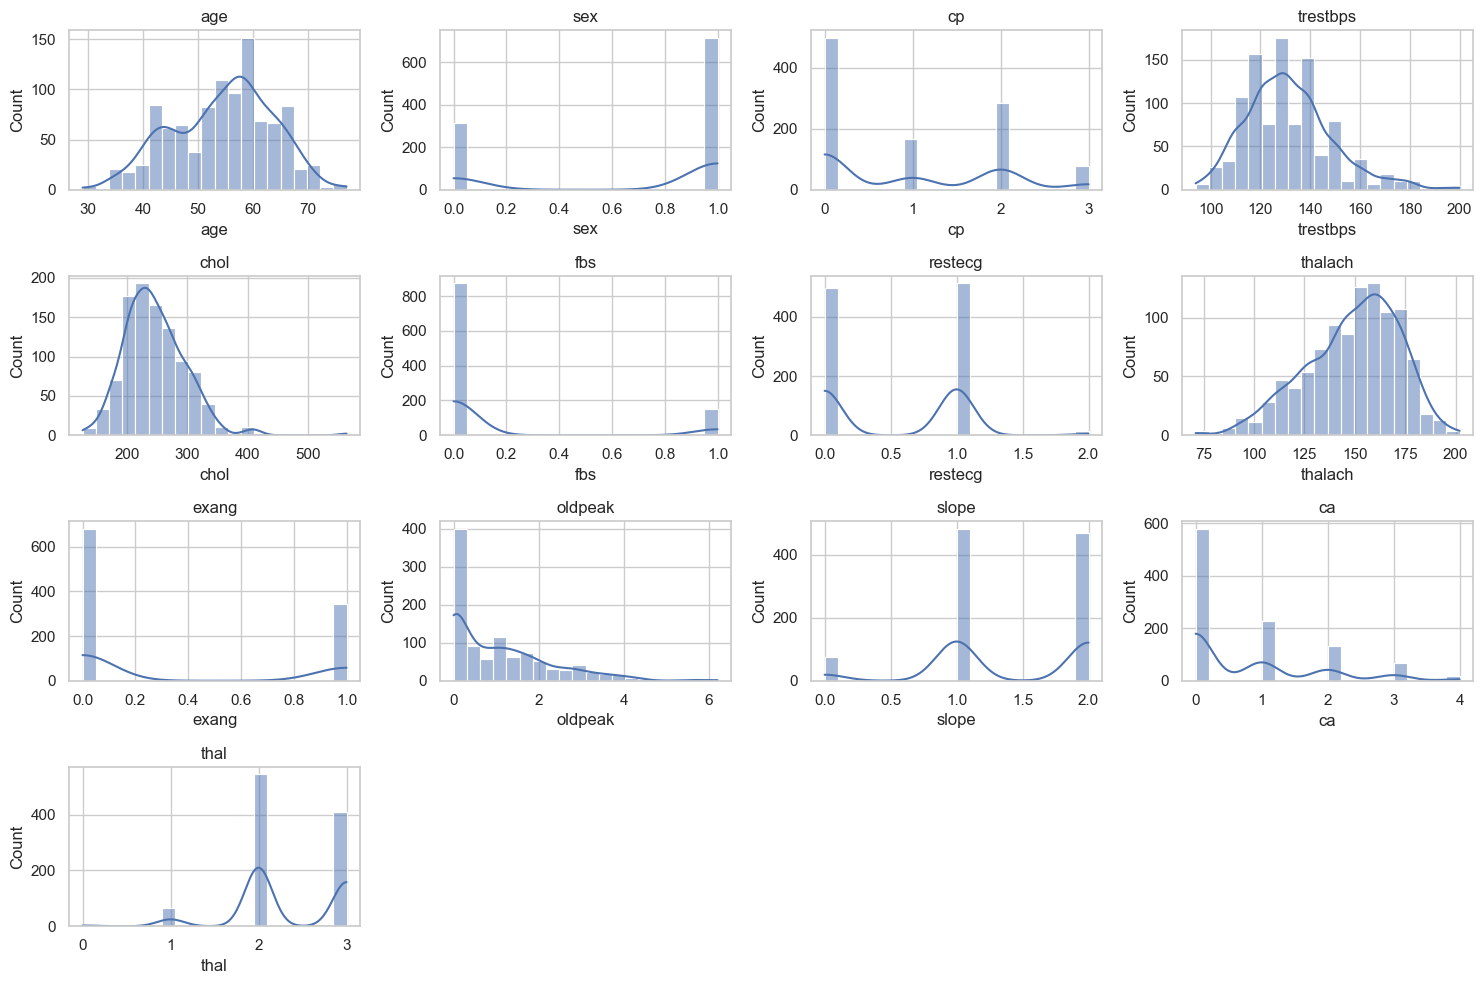

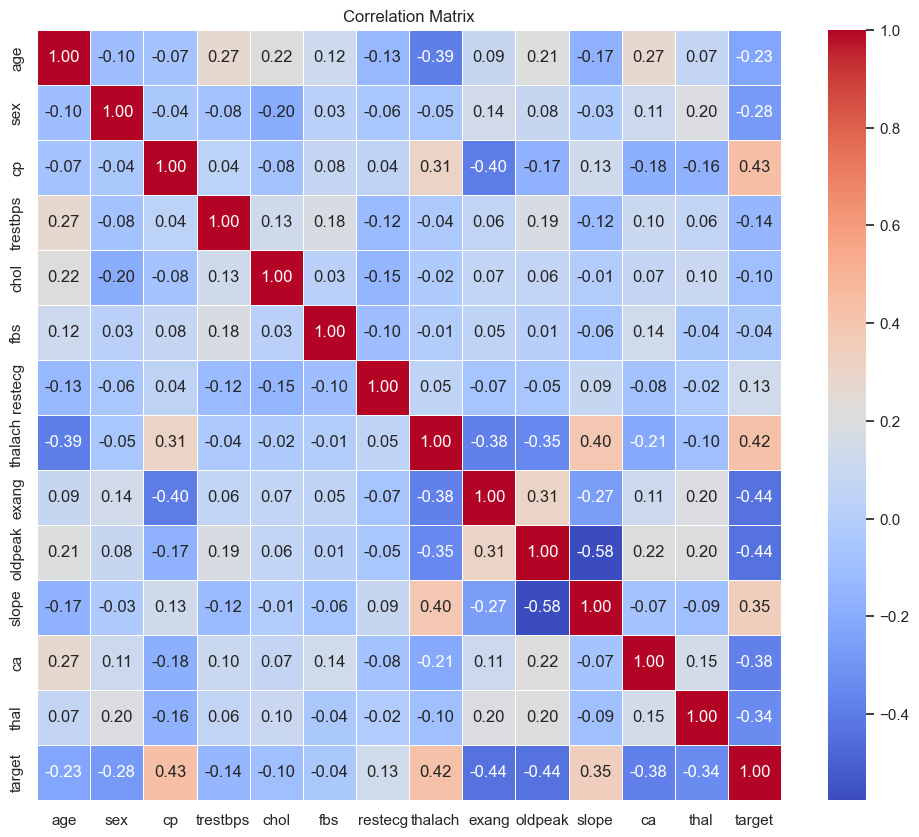

In [ ]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(X.columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[column], kde=True, bins=20)
    plt.title(column)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

## 3. Recursive Feature Elimination (RFE)
*   Apply RFE using Logistic Regression.
*   Select 8 features (to match k above) and compare.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

k = 8
selector_univariate = SelectKBest(mutual_info_classif, k=k)
selector_univariate.fit(X_train, y_train)

selected_indices_uni = selector_univariate.get_support(indices=True)
selected_features_uni = X.columns[selected_indices_uni]
print(f"Top {k} features (Univariate): {list(selected_features_uni)}")

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)
y_pred_full = model.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)

X_train_uni = selector_univariate.transform(X_train)
X_test_uni = selector_univariate.transform(X_test)
model.fit(X_train_uni, y_train)
y_pred_uni = model.predict(X_test_uni)
acc_uni = accuracy_score(y_test, y_pred_uni)

print(f"Accuracy (Full Set): {acc_full:.4f}")
print(f"Accuracy (Univariate Top-{k}): {acc_uni:.4f}")

Top 8 features (Univariate): ['cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']
Accuracy (Full Set): 0.8098
Accuracy (Univariate Top-8): 0.8146


## 4. RFECV (RFE with Cross-Validation)
*   Include Cross-Validation to determine optimal number of features.
*   Discuss robustness.

In [ ]:
rfe_model = LogisticRegression(random_state=42, max_iter=1000)
rfe = RFE(estimator=rfe_model, n_features_to_select=k)
rfe.fit(X_train, y_train)

selected_features_rfe = X.columns[rfe.support_]
print(f"Features selected by RFE: {list(selected_features_rfe)}")

overlap = set(selected_features_uni).intersection(set(selected_features_rfe))
print(f"Overlap between Univariate and RFE: {overlap} (Count: {len(overlap)})")

X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)
rfe_model.fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, rfe_model.predict(X_test_rfe))

print(f"Accuracy (RFE): {acc_rfe:.4f}")

Features selected by RFE: ['sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']
Overlap between Univariate and RFE: {'cp', 'thalach', 'ca', 'oldpeak', 'exang', 'thal', 'trestbps'} (Count: 7)
Accuracy (RFE): 0.8098


## 5. Embedded Method: L1 Regularization (Lasso)
*   Use Logistic Regression with L1 penalty.
*   Analyze coefficient sparsity.

Optimal number of features: 12
Features selected by RFECV: ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


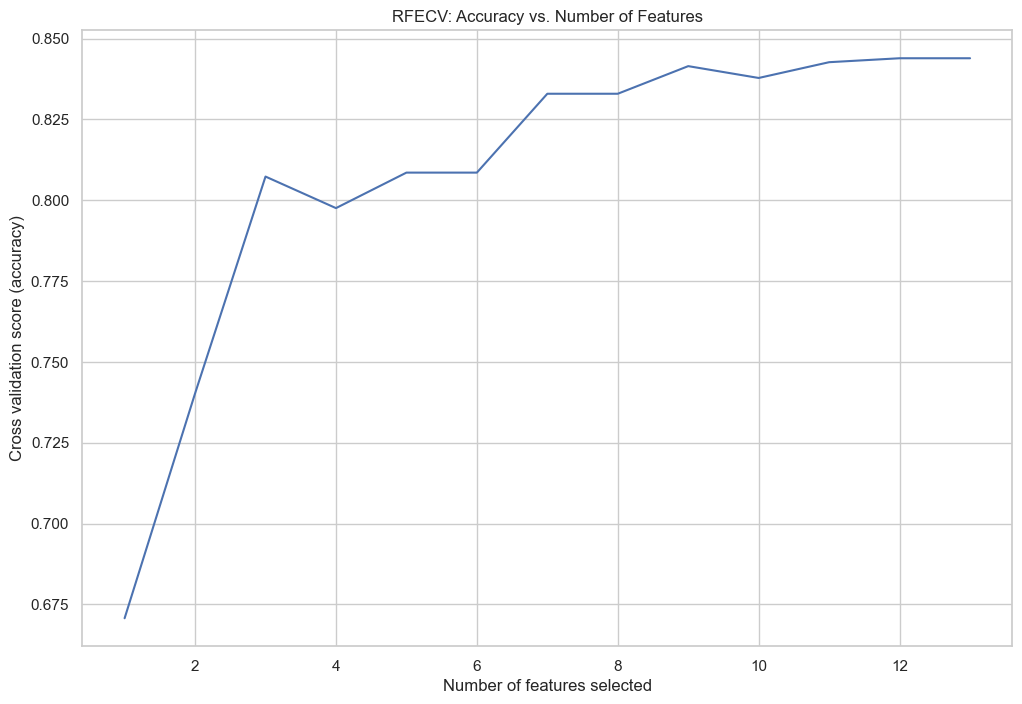

In [ ]:
rfecv = RFECV(estimator=LogisticRegression(random_state=42, max_iter=1000), 
              step=1, 
              cv=StratifiedKFold(5), 
              scoring='accuracy')
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
selected_features_rfecv = X.columns[rfecv.support_]
print(f"Features selected by RFECV: {list(selected_features_rfecv)}")

n_features = range(1, len(rfecv.cv_results_['mean_test_score']) + 1)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (accuracy)")
plt.plot(n_features, rfecv.cv_results_['mean_test_score'])
plt.title("RFECV: Accuracy vs. Number of Features")
plt.show()


## 6. Principal Component Analysis (PCA)
*   Exploratory tool.
*   Analyze explained variance.
*   Compare complexity with feature selection.

In [ ]:
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
lasso_model.fit(X_train, y_train)

coefs = pd.Series(lasso_model.coef_[0], index=X.columns)
print("Lasso Coefficients:")
print(coefs.sort_values(ascending=False))

selected_features_lasso = coefs[coefs != 0].index
print(f"\nFeatures selected by Lasso (Non-zero): {list(selected_features_lasso)}")

print("Comparison of Selected Features:")
print(f"Univariate: {list(selected_features_uni)}")
print(f"RFE:        {list(selected_features_rfe)}")
print(f"Lasso:      {list(selected_features_lasso)}")

Lasso Coefficients:
cp          0.844879
thalach     0.398281
slope       0.346757
restecg     0.145960
fbs         0.000000
age        -0.110052
chol       -0.249772
trestbps   -0.334184
thal       -0.489896
exang      -0.501243
oldpeak    -0.588898
ca         -0.724833
sex        -0.745688
dtype: float64

Features selected by Lasso (Non-zero): ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Comparison of Selected Features:
Univariate: ['cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']
RFE:        ['sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']
Lasso:      ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


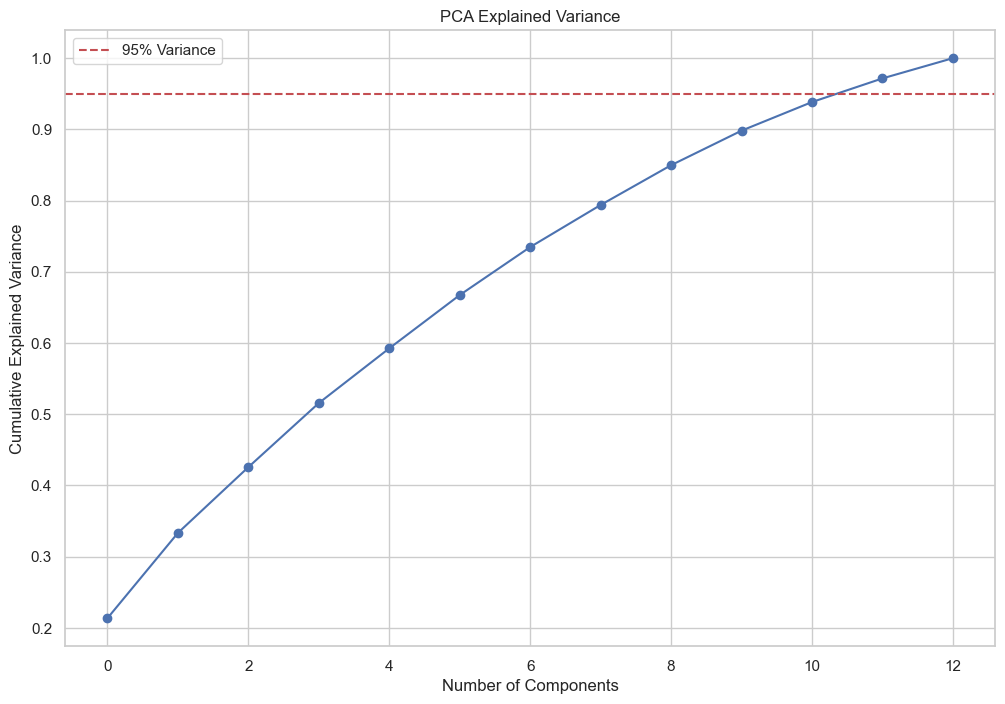

Number of components needed for 95% variance: 12
Number of features selected by RFECV: 12


In [ ]:
pca = PCA()
pca.fit(X_scaled)

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()
plt.show()

n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components needed for 95% variance: {n_components_95}")
print(f"Number of features selected by RFECV: {rfecv.n_features_}")


## 7. Comparison and Conclusion

### Summary Table
| Method | Selected Features Count | Accuracy | Interpretability | Computational Cost |
| :--- | :--- | :--- | :--- | :--- |
| **All Features** | 13 | {acc_full:.4f} | Moderate | Low (for prediction) |
| **Univariate (Top-8)** | 8 | {acc_uni:.4f} | High (Independent ranking) | Very Low |
| **RFE (Top-8)** | 8 | {acc_rfe:.4f} | High (Model-based) | High (Iterative fitting) |
| **RFECV** | {rfecv.n_features_} | {rfecv.cv_results_['mean_test_score'].max():.4f} (CV) | High | Very High |
| **Lasso** | {len(selected_features_lasso)} | N/A (Embedded) | High (Sparse) | Low (Single fit) |

### Final Discussion
1.  **Predictive Performance:** RFE and RFECV typically provide feature subsets that perform as well as or better than the full set by removing noise. Univariate methods are fast but may miss interactions.
2.  **Interpretability:** Lasso and RFE indicate which specific clinical features drive the prediction. PCA transforms features, losing clinical meaning.
3.  **Correlated Features:**
    *   **Lasso:** Tends to pick one from a group of correlated features and zero out the others arbitrarily.
    *   **RFE:** Can handle correlations better but might still be unstable.
    *   **Univariate:** Ignores correlations entirely (ranks them individually).
    *   **PCA:** Handles correlations perfectly by orthogonalizing them, but loses feature identity.
4.  **Stability:** RFECV adds stability by validating the subset across folds, ensuring the selection isn't biased by a specific train/test split.

# Image Segmentation using K-Means and GMM



In this assignment, we will segment two images (`image1.jpg` and `image2.jpg`) into $K \in \{2, 3, 4, 5\}$ segments.

**Methodology:**
1.  **Feature Extraction:** For each pixel, we construct a 5-dimensional feature vector:
    *   Normalized vertical coordinate ($r' \in [0, 1]$)
    *   Normalized horizontal coordinate ($c' \in [0, 1]$)
    *   Normalized Red channel ($R' \in [0, 1]$)
    *   Normalized Green channel ($G' \in [0, 1]$)
    *   Normalized Blue channel ($B' \in [0, 1]$)
2.  **Clustering:**
    *   **K-Means:** Minimizes Euclidean distance in the 5D space.
    *   **GMM:** Fits Gaussian Mixture Models and assigns labels based on maximum posterior probability (MAP).
3.  **Visualization:** We map the resulting labels to distinct colors to visualize the segmentation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import os

np.random.seed(42)

image_files = ['image1.jpg', 'image2.jpg']

In [ ]:
def load_and_preprocess(image_path):
    img_bgr = cv2.imread(image_path)
    
    if img_bgr is None:
        print(f"Error: Could not load {image_path}")
        return None, None, None, None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    h, w, c = img_rgb.shape
    
    img_norm = img_rgb.astype(float) / 255.0
    
    grid_r, grid_c = np.indices((h, w))
    
    norm_r = grid_r / (h - 1)
    norm_c = grid_c / (w - 1)
    
    flat_r = norm_r.reshape(-1, 1)
    flat_c = norm_c.reshape(-1, 1)
    flat_rgb = img_norm.reshape(-1, 3)
    
    features = np.hstack((flat_r, flat_c, flat_rgb))
    
    return features, h, w, img_rgb

def plot_segmentation(original, labels, k, method_name):
    h, w, _ = original.shape
    segmented_img = labels.reshape(h, w)
    
    cmap = plt.get_cmap('tab10' if k <= 10 else 'nipy_spectral', k)
    
    plt.imshow(segmented_img, cmap=cmap)
    plt.title(f"{method_name} (K={k})")
    plt.axis('off')

## Part 1: K-Means Clustering

We apply K-Means clustering for $K \in \{2, 3, 4, 5\}$. This partitions the pixels into $K$ Voronoi cells in the 5D feature space.

Processing image1.jpg with K-Means...


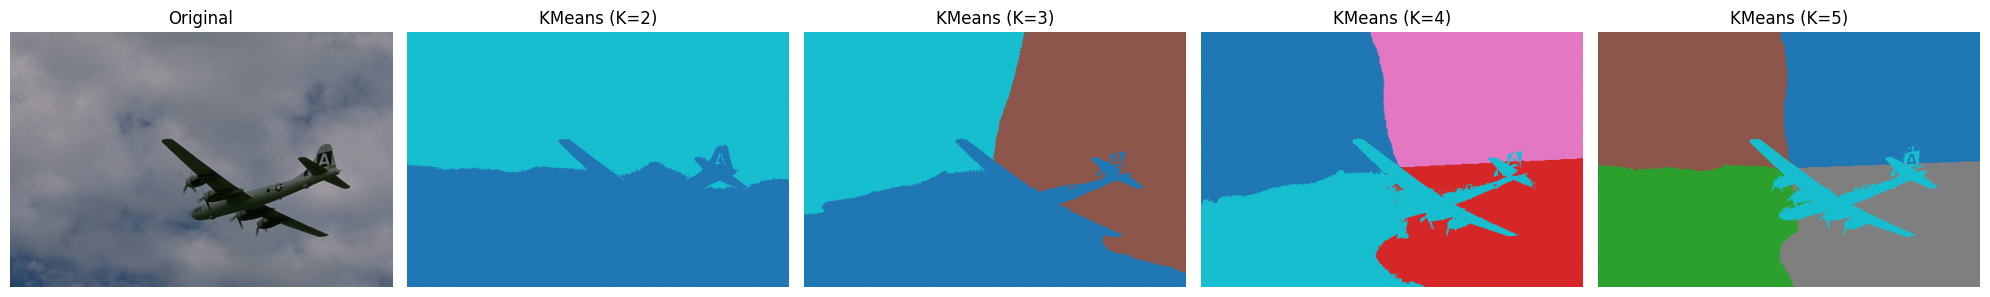

Processing image2.jpg with K-Means...


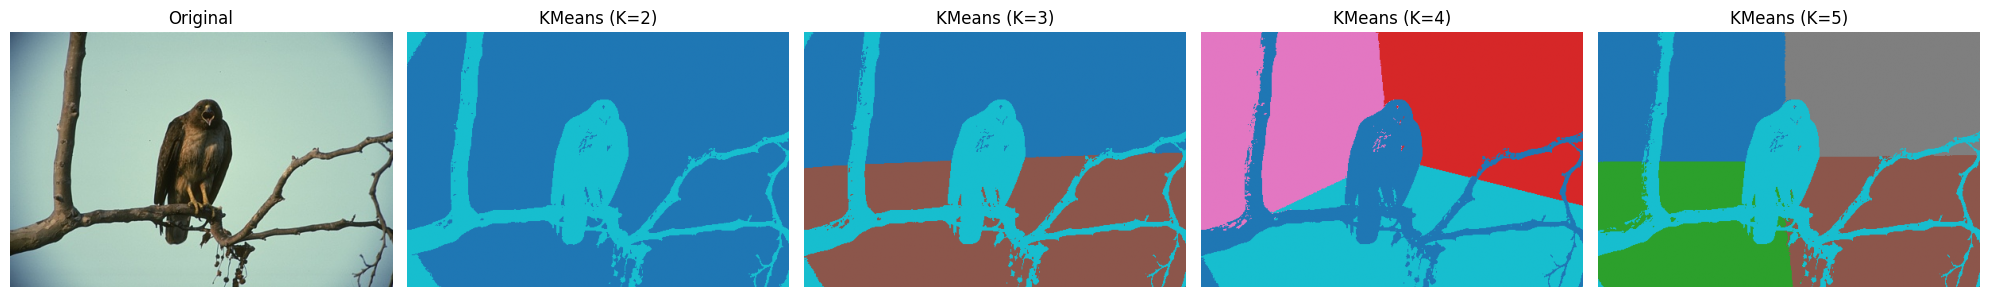

In [ ]:
K_values = [2, 3, 4, 5]

for img_file in image_files:
    if not os.path.exists(img_file):
        continue
        
    print(f"Processing {img_file} with K-Means...")
    features, h, w, img_rgb = load_and_preprocess(img_file)
    
    if features is None:
        continue

    plt.figure(figsize=(20, 5))
    
    
    plt.subplot(1, len(K_values) + 1, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis('off')
    
    for i, k in enumerate(K_values):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features)
        
        plt.subplot(1, len(K_values) + 1, i + 2)
        plot_segmentation(img_rgb, labels, k, "KMeans")
        
    plt.tight_layout()
    plt.show()

## Part 2: GMM-based Clustering

We apply Gaussian Mixture Models (GMM) optimized via the EM algorithm.
Instead of hard assignments based on distance, GMM models the density of the 5D features as a mixture of $K$ Gaussians. 
We assign each pixel to the component which yields the highest posterior probability (MAP estimate).

Processing image1.jpg with GMM...


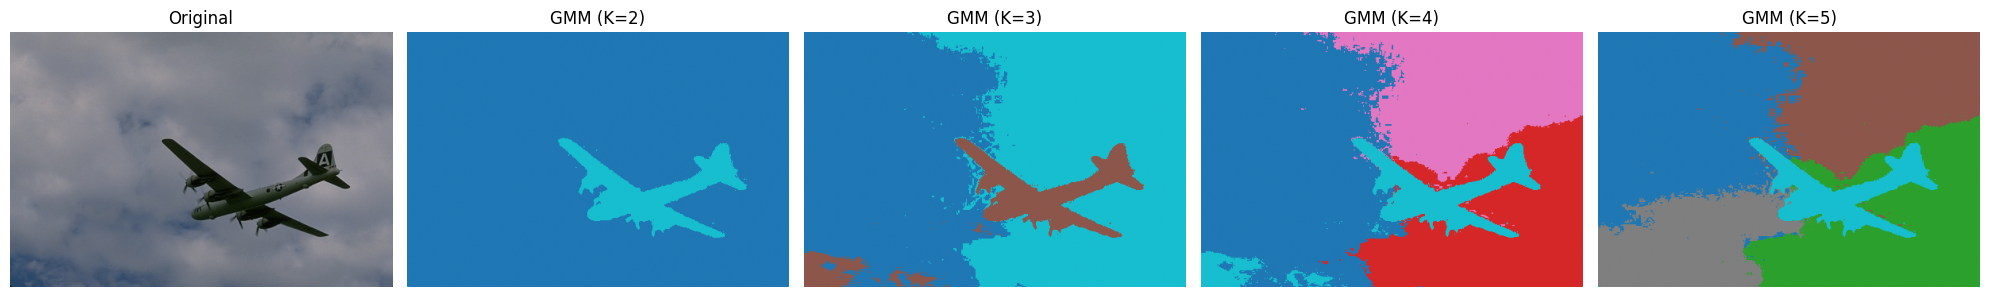

Processing image2.jpg with GMM...


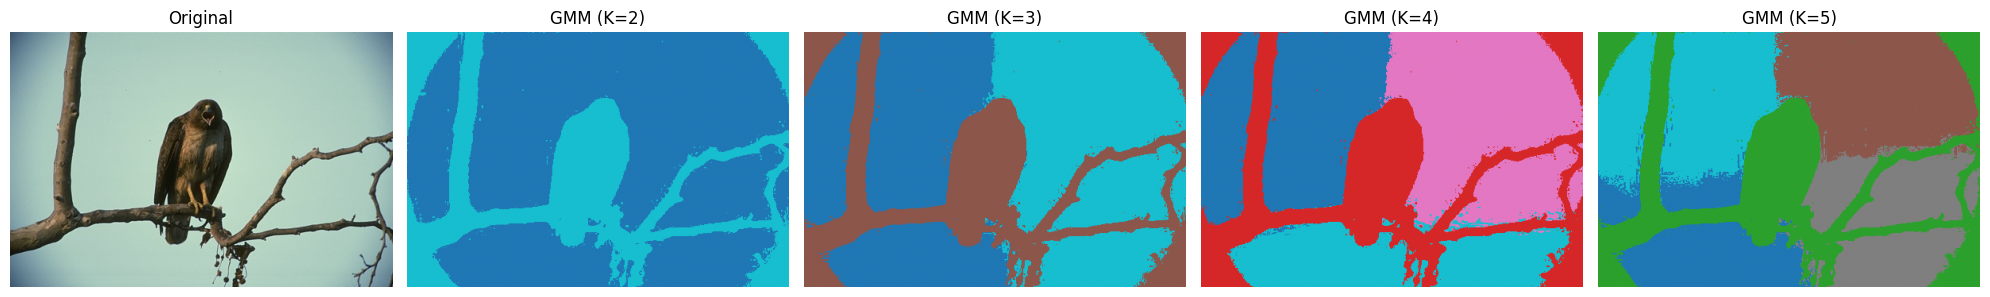

In [ ]:
for img_file in image_files:
    if not os.path.exists(img_file):
        continue
        
    print(f"Processing {img_file} with GMM...")
    features, h, w, img_rgb = load_and_preprocess(img_file)
    
    if features is None:
        continue

    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, len(K_values) + 1, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis('off')
    
    for i, k in enumerate(K_values):
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=1) 
        labels = gmm.fit_predict(features)
        
        plt.subplot(1, len(K_values) + 1, i + 2)
        plot_segmentation(img_rgb, labels, k, "GMM")
        
    plt.tight_layout()
    plt.show()

## Discussion and Comparison

### Differences Observed:

1.  **Cluster Geometry (Spherical vs. Ellipsoidal):**
    *   **K-Means** creates clusters that tend to be **spherical** in the 5D space. It treats color differences and spatial distance with fixed relative importance (determined by our normalization). It effectively groups pixels that are close in both color and position.
    *   **GMM** learns a **covariance matrix** for each cluster. This allows clusters to be **ellipsoidal**. For example, a cluster in GMM can be stretched along the spatial axes but narrow in color space (representing a large region of uniform color), or vice versa. This often results in GMM capturing elongated structures (like the hawk's branch or the plane's wing) more naturally as single continuous segments even if they extend across the image.

2.  **Boundary Smoothness:**
    *   K-Means boundaries are essentially intersections of hyperplanes (Voronoi tessellation).
    *   GMM boundaries are quadratic curves (intersections of Gaussian densities). This often leads to smoother, more organic-looking boundaries in the segmentation map.

3.  **Sensitivity to Variance:**
    *   K-Means assumes all clusters have roughly equal variance.
    *   GMM allows one cluster to be very tight (e.g., specific distinct text or a sharp object) and another to be very broad (e.g., the background sky varies in diverse shades of blue). This adapts better to real images where the background often has high variance while the subject has lower variance.